In [2]:
# __________CELL 1___________
# This cell installs the extra packages needed for the notebook.
# I kept this at the top so the notebook can be rerun on a new machine or environment
# without the reader having to guess which libraries the project depends on.

!pip install kagglehub shap joblib imbalanced-learn


   ---------------------------------------- 0/5 [pyyaml]
   -------- ------------------------------- 1/5 [kagglesdk]
   -------- ------------------------------- 1/5 [kagglesdk]
   -------- ------------------------------- 1/5 [kagglesdk]
   -------- ------------------------------- 1/5 [kagglesdk]
   -------- ------------------------------- 1/5 [kagglesdk]
   -------- ------------------------------- 1/5 [kagglesdk]
   -------- ------------------------------- 1/5 [kagglesdk]
   -------- ------------------------------- 1/5 [kagglesdk]
   -------- ------------------------------- 1/5 [kagglesdk]
   ---------------- ----------------------- 2/5 [sklearn-compat]
   ------------------------ --------------- 3/5 [kagglehub]
   ------------------------ --------------- 3/5 [kagglehub]
   ------------------------ --------------- 3/5 [kagglehub]
   -------------------------------- ------- 4/5 [imbalanced-learn]
   -------------------------------- ------- 4/5 [imbalanced-learn]
   --------------------

In [3]:
# __________CELL 2___________
# This cell checks which Python environment is running the notebook.
# I used this mainly to confirm that the notebook was using the correct virtual environment,
# because package issues are much easier to debug when the Python path is visible.
# And I had quite a number of issues
import sys
print(sys.executable)
print(sys.version)

c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\.venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [4]:
# __________CELL 3___________
# This cell checks that the certificate file used by Python requests exists.
# This was useful during setup because KaggleHub needs internet access,
# and certificate issues can stop the dataset from downloading properly.

import certifi
from pathlib import Path

print(certifi.where())
print(Path(certifi.where()).exists())

c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\.venv\Lib\site-packages\certifi\cacert.pem
True


In [5]:
# __________CELL 4___________
# This short check confirms that KaggleHub imports correctly before the dataset is downloaded.
# It is a simple setup test, but it saves time because any package issue appears before
# the main data-loading cells are run.

import kagglehub
print("kagglehub imported ok")

kagglehub imported ok


c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# __________CELL 5___________
# This cell sets up the main project folders for saved models and exported data.
# The notebook may be run from the main project folder or from inside the notebooks folder,
# so this keeps the paths consistent either way.

from pathlib import Path

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent

MODELS_DIR = ROOT_DIR / "models"
DATA_DIR   = ROOT_DIR / "data"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

In [7]:
# __________CELL 6___________
# This cell imports the main libraries and sets the project configuration values.
# I put the important settings here, such as the random seed, test size, target horizon
# and cleaning options, so the experiment can be repeated without hidden manual changes.

import os, glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
import shap
import joblib

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
TEST_SIZE = 0.2

GROUP_COL = "Patient_ID"
RAW_LABEL = "SepsisLabel"

HORIZON_HOURS = 6

EXPERIMENT_NAME = "subset_5000"
RUN_NOTES = "baseline subset"

USE_SUBSET_FOR_SPEED = True
N_PATIENTS_SUBSET = 5000

DROP_HOUR_IF_ICULOS = True
DROP_ULTRA_MISSING = True
MISSING_THRESHOLD = 0.98
CLEAN_OUTLIERS = True

t_pipeline_start = time.perf_counter()



In [8]:

# __________CELL 7___________
# This cell downloads the sepsis dataset through KaggleHub and loads it into a dataframe.
# Downloading it through code keeps the workflow reproducible, instead of relying on
# manually placed files that could move, be renamed.

path = kagglehub.dataset_download("salikhussaini49/prediction-of-sepsis")
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
assert len(csv_files) > 0, "No CSV found"

df = pd.read_csv(csv_files[0])
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Original shape:", df.shape)
df[RAW_LABEL] = df[RAW_LABEL].astype(int)
print("Raw label distribution:\n", df[RAW_LABEL].value_counts(normalize=True))

100%|██████████| 74.7M/74.7M [00:17<00:00, 4.38MB/s]

Extracting files...


Original shape: (1552210, 43)
Raw label distribution:
 SepsisLabel
0    0.982015
1    0.017985
Name: proportion, dtype: float64


In [9]:
# __________CELL 8___________
# This cell creates the early-warning target used for the project.
# The original label only says whether sepsis is present at that hour, so this code looks ahead
# within each patient's timeline and marks rows where sepsis is coming soon but is not already present.

df = df.sort_values([GROUP_COL, "ICULOS"]).copy()

def future_max_excluding_now(s, H):
    rev = s.iloc[::-1]
    fut = rev.rolling(window=H, min_periods=1).max().shift(1)
    return fut.iloc[::-1]

df["SepsisInNextXH"] = (
    df.groupby(GROUP_COL)[RAW_LABEL]
      .transform(lambda s: future_max_excluding_now(s, HORIZON_HOURS))
      .fillna(0).astype(int)
)

df["SepsisInNext1H"] = (
    df.groupby(GROUP_COL)[RAW_LABEL]
      .shift(-1).fillna(0).astype(int)

)

df["SepsisEarlyWarning"] = (
    (df["SepsisInNextXH"] == 1) &
    (df["SepsisInNext1H"] == 0) &
    (df[RAW_LABEL] == 0)
).astype(int)

TARGET = "SepsisEarlyWarning"

print("\nSepsisInNextXH:\n", df["SepsisInNextXH"].value_counts())
print("\nSepsisEarlyWarning:\n", df[TARGET].value_counts(normalize=True))


SepsisInNextXH:
 SepsisInNextXH
0    1513147
1      39063
Name: count, dtype: int64

 SepsisEarlyWarning
0    0.992544
1    0.007456
Name: proportion, dtype: float64


In [10]:
# __________CELL 9___________
# This cell reduces the dataset to a reproducible subset of patients for development speed.
# The subset is selected by patient rather than by random rows, so the time structure of each chosen
# patient is still preserved while keeping the experiment manageable.

if USE_SUBSET_FOR_SPEED:
    rng = np.random.RandomState(RANDOM_STATE)
    keep = rng.choice(df[GROUP_COL].unique(), size=min(N_PATIENTS_SUBSET, df[GROUP_COL].nunique()), replace=False)
    df = df[df[GROUP_COL].isin(keep)].copy()
    print("\nSUBSET MODE ON:", df.shape, "| patients:", df[GROUP_COL].nunique())


SUBSET MODE ON: (191583, 46) | patients: 5000


In [11]:
# __________CELL 10___________
# This cell prints the experiment settings and dataset size after subsetting.
# It gives a quick record of how many rows and patients were actually used in this run,
# which is useful when comparing results later.

print(f"Experiment: {EXPERIMENT_NAME}")
print(f"USE_SUBSET_FOR_SPEED = {USE_SUBSET_FOR_SPEED}")

if USE_SUBSET_FOR_SPEED:
    print(f"N_PATIENTS_SUBSET = {N_PATIENTS_SUBSET}")

print(f"Rows used: {len(df):,}")
print(f"Patients used: {df[GROUP_COL].nunique():,}")

Experiment: subset_5000
USE_SUBSET_FOR_SPEED = True
N_PATIENTS_SUBSET = 5000
Rows used: 191,583
Patients used: 5,000


In [12]:
# __________CELL 11___________
# This cell removes columns that are missing in almost all rows.
# Keeping columns with extreme missingness would add very little useful information
# and could make the model rely on noise rather than meaningful clinical patterns.

missing = df.drop(columns=[TARGET]).isna().mean()
if DROP_ULTRA_MISSING:
    drop_missing_cols = missing[missing >= MISSING_THRESHOLD].index.tolist()
    drop_missing_cols = [c for c in drop_missing_cols if c not in [TARGET, GROUP_COL]]
    if drop_missing_cols:
        df = df.drop(columns=drop_missing_cols)
    print("\nDropped", len(drop_missing_cols), "ultra-missing columns:", drop_missing_cols)


Dropped 6 ultra-missing columns: ['AST', 'Alkalinephos', 'Bilirubin_direct', 'Bilirubin_total', 'TroponinI', 'Fibrinogen']


In [13]:
# __________CELL 12___________
# This cell marks physiologically unrealistic values as missing rather than treating them as real readings.
# This is safer than leaving impossible values in the data, because later the pipeline can impute them
# instead of letting the model learn from unrealistic values. 

def set_out_of_range_to_nan(df_, col, low=None, high=None):
    if col not in df_.columns:
        return
    s = df_[col]
    mask = pd.Series(False, index=s.index)
    if low is not None:  mask |= (s < low)
    if high is not None: mask |= (s > high)
    df_.loc[mask, col] = np.nan

if CLEAN_OUTLIERS:
    set_out_of_range_to_nan(df, "FiO2", low=0.21, high=1.00)
    set_out_of_range_to_nan(df, "Temp", low=25.0, high=45.0)
    set_out_of_range_to_nan(df, "HR",   low=20.0, high=250.0)
    set_out_of_range_to_nan(df, "SBP",  low=40.0, high=300.0)
    set_out_of_range_to_nan(df, "DBP",  low=20.0, high=200.0)
    set_out_of_range_to_nan(df, "MAP",  low=20.0, high=250.0)
    set_out_of_range_to_nan(df, "Resp", low=1.0,  high=80.0)
    set_out_of_range_to_nan(df, "O2Sat",low=50.0, high=100.0)


In [14]:
# __________CELL 13___________
# This cell creates the feature matrix and target while removing columns that would leak the answer.
# The helper labels are useful for building the target, but they must not be given to the model,
# otherwise the evaluation would look better than it really is.

LEAKAGE_COLS = ["SepsisLabel", "SepsisInNextXH", "SepsisInNext1H"]
drop_cols = [TARGET] + LEAKAGE_COLS + [GROUP_COL]
if DROP_HOUR_IF_ICULOS and ("Hour" in df.columns) and ("ICULOS" in df.columns):
    drop_cols.append("Hour")

y = df[TARGET].astype(int)
X = df.drop(columns=[c for c in drop_cols if c in df.columns])

assert all(c not in X.columns for c in LEAKAGE_COLS), "Leakage columns found in X"
print("\nX/y shapes:", X.shape, y.shape)


X/y shapes: (191583, 34) (191583,)


In [15]:
# __________CELL 13B___________
# Technical validation: confirming that the leakage columns are not included as the model features.
# This checks that target/future-label columns and patient identifiers were removed from X.

blocked_cols = [TARGET] + LEAKAGE_COLS + [GROUP_COL]

if DROP_HOUR_IF_ICULOS and ("Hour" in df.columns) and ("ICULOS" in df.columns):
    blocked_cols.append("Hour")

blocked_cols_in_X = [col for col in blocked_cols if col in X.columns]

print("Blocked/leakage columns checked:", blocked_cols)
print("Blocked/leakage columns found in X:", blocked_cols_in_X)
print("Final feature matrix shape:", X.shape)

assert len(blocked_cols_in_X) == 0, "Blocked or leakage columns are still present in X"

Blocked/leakage columns checked: ['SepsisEarlyWarning', 'SepsisLabel', 'SepsisInNextXH', 'SepsisInNext1H', 'Patient_ID', 'Hour']
Blocked/leakage columns found in X: []
Final feature matrix shape: (191583, 34)


In [16]:
# __________CELL 14___________
# This cell splits the data into training and test sets by patient ID.
# This matters because each patient has many hourly rows, so a normal row-level split
# could put the same patient into both training and testing, which would make the result misleading.

groups = df[GROUP_COL]
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [17]:
# __________CELL 15___________
# This cell creates the demo patient files used by the Streamlit dashboard.
# The important point is that the demo patients come only from the held-out test split,
# so the dashboard does not accidentally show patients the model was trained on.

import json

DEMO_PATIENTS = 200
DEMO_SOURCE = "held_out_test_patients_only"

demo_time_col = "ICULOS" if "ICULOS" in df.columns else "Hour"

test_df = df.loc[X_test.index].copy()

rng = np.random.RandomState(RANDOM_STATE)
test_patient_ids = test_df[GROUP_COL].unique()

demo_ids = rng.choice(
    test_patient_ids,
    size=min(DEMO_PATIENTS, len(test_patient_ids)),
    replace=False
)

demo_raw = (
    test_df[test_df[GROUP_COL].isin(demo_ids)]
    .sort_values([GROUP_COL, demo_time_col])
    .copy()
)

demo_X = X.loc[demo_raw.index].copy().reset_index(drop=True)
demo_df = demo_raw.reset_index(drop=True)

train_patient_ids = set(groups.iloc[train_idx].unique())
test_patient_ids_set = set(groups.iloc[test_idx].unique())
demo_patient_ids_set = set(demo_df[GROUP_COL].unique())

assert demo_patient_ids_set.issubset(test_patient_ids_set), "Demo patients are not all from test split"
assert demo_patient_ids_set.isdisjoint(train_patient_ids), "Demo patients overlap with training patients"
assert len(demo_df) == len(demo_X), "demo_df and demo_X row counts do not match"

demo_df.to_parquet(DATA_DIR / "demo_df.parquet", index=False)
demo_X.to_parquet(DATA_DIR / "demo_X.parquet", index=False)

demo_meta = {
    "source": DEMO_SOURCE,
    "demo_patients_requested": int(DEMO_PATIENTS),
    "demo_patients_saved": int(demo_df[GROUP_COL].nunique()),
    "rows_saved": int(len(demo_df)),
    "all_from_test_split": True,
}

with open(DATA_DIR / "demo_metadata.json", "w", encoding="utf-8") as f:
    json.dump(demo_meta, f, indent=2)

print("Saved:", DATA_DIR / "demo_df.parquet")
print("Saved:", DATA_DIR / "demo_X.parquet")
print("Saved:", DATA_DIR / "demo_metadata.json")
print("Demo source:", DEMO_SOURCE)
print("Rows:", len(demo_df), "| Patients:", demo_df[GROUP_COL].nunique())

Saved: c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\data\demo_df.parquet
Saved: c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\data\demo_X.parquet
Saved: c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\data\demo_metadata.json
Demo source: held_out_test_patients_only
Rows: 8159 | Patients: 200


In [18]:
# __________CELL 15B___________
# Technical validation: confirming that the demo patients only come from the held-out test split.

print("Demo patients saved:", len(demo_patient_ids_set))
print("Demo patients all from test split:", demo_patient_ids_set.issubset(test_patient_ids_set))
print("Demo/train patient overlap:", len(demo_patient_ids_set.intersection(train_patient_ids)))

assert demo_patient_ids_set.issubset(test_patient_ids_set), "Demo patients are not all from test split"
assert len(demo_patient_ids_set.intersection(train_patient_ids)) == 0, "Demo patients overlap with training patients"

Demo patients saved: 200
Demo patients all from test split: True
Demo/train patient overlap: 0


In [19]:
# __________CELL 16___________
# This cell creates a validation set from the non-test data, again split by patient.
# The validation set is used for model selection and threshold selection, which means
# the final test set can stay untouched until the end.

X_train_full = X_train
y_train_full = y_train
groups_train = groups.iloc[train_idx]   

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train2_idx, val_idx = next(gss2.split(X_train_full, y_train_full, groups=groups_train))

X_train2 = X_train_full.iloc[train2_idx]
y_train2 = y_train_full.iloc[train2_idx]

X_val = X_train_full.iloc[val_idx]
y_val = y_train_full.iloc[val_idx]

print("Train2:", X_train2.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train2: (122367, 34) | Val: (29881, 34) | Test: (39335, 34)


In [20]:
# __________CELL 16B___________
# Technical validation: confirming that none of the patients appear in more than one split.
# This prevents patient leakage because each patient has multiple hourly observations.

train2_patients = set(groups_train.iloc[train2_idx].astype(str))
val_patients = set(groups_train.iloc[val_idx].astype(str))
test_patients = set(groups.iloc[test_idx].astype(str))

train_val_overlap = train2_patients.intersection(val_patients)
train_test_overlap = train2_patients.intersection(test_patients)
val_test_overlap = val_patients.intersection(test_patients)

print("Training patients:", len(train2_patients))
print("Validation patients:", len(val_patients))
print("Testing patients:", len(test_patients))

print("Train/validation patient overlap:", len(train_val_overlap))
print("Train/test patient overlap:", len(train_test_overlap))
print("Validation/test patient overlap:", len(val_test_overlap))

assert len(train_val_overlap) == 0, "Patient leakage detected between training and validation sets"
assert len(train_test_overlap) == 0, "Patient leakage detected between training and test sets"
assert len(val_test_overlap) == 0, "Patient leakage detected between validation and test sets"

Training patients: 3200
Validation patients: 800
Testing patients: 1000
Train/validation patient overlap: 0
Train/test patient overlap: 0
Validation/test patient overlap: 0


In [21]:
# __________CELL 17___________
# This cell checks that all earlier variables exist before the main model-selection stage runs.
# It also sets the threshold policy, alert hygiene rules and SHAP sample size in one place,
# so the later evaluation is easier to follow and repeat.

try:
    from IPython.display import display
except Exception:
    display = print

required_vars = [
    "df", "X",
    "X_train2", "y_train2",
    "X_val", "y_val",
    "X_test", "y_test",
    "GROUP_COL", "RANDOM_STATE",
    "TARGET", "RAW_LABEL",
    "HORIZON_HOURS", "TEST_SIZE",
    "USE_SUBSET_FOR_SPEED", "N_PATIENTS_SUBSET",
    "DROP_ULTRA_MISSING", "MISSING_THRESHOLD",
    "CLEAN_OUTLIERS"
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(f"Missing variables from earlier cells: {missing_vars}. Run cells up to 8.5 first.")

try:
    MODELS_DIR
except NameError:
    MODELS_DIR = Path("models")
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

try:
    DATA_DIR
except NameError:
    DATA_DIR = Path("data")
    DATA_DIR.mkdir(parents=True, exist_ok=True)




FORCE_MODEL = None          
PR_AUC_TIE_TOL = 0.001      

if FORCE_MODEL not in [None, "rf", "lr"]:
    raise ValueError("FORCE_MODEL must be None, 'rf', or 'lr'")


MIN_PRECISION_RED = 0.20
MIN_RECALL_AMBER  = 0.60


K_CONSECUTIVE_AMBER = 2
K_CONSECUTIVE_RED   = 1
COOLDOWN_HOURS      = 6
ALLOW_ESCALATION_TO_RED = True


N_SHAP = 200


TIME_COL = "ICULOS" if ("ICULOS" in df.columns) else ("Hour" if ("Hour" in df.columns) else None)
if TIME_COL is None:
    raise ValueError("Need a time column for alert hygiene. Expected 'ICULOS' or 'Hour' in df.")

print("Setup OK.")
print("TIME_COL =", TIME_COL)
print("MODELS_DIR =", MODELS_DIR)
print("DATA_DIR   =", DATA_DIR)

Setup OK.
TIME_COL = ICULOS
MODELS_DIR = c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\models
DATA_DIR   = c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\data


In [22]:
# __________CELL 18___________
# This cell defines the helper functions used for evaluation and alert behaviour.
# These functions keep the later cells cleaner by separating repeated tasks such as scoring,
# choosing thresholds, applying alert hygiene and printing reports.

def eval_on_split(name, model, X_eval, y_eval):
    proba = model.predict_proba(X_eval)[:, 1]
    metrics = {
        "Model": name,
        "ROC_AUC": float(roc_auc_score(y_eval, proba)),
        "PR_AUC": float(average_precision_score(y_eval, proba)),
        "Pos_rate": float(np.mean(y_eval)),
    }
    return metrics, proba

def pick_threshold_for_precision(y_true, proba, min_precision=0.20):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    precision2 = precision[:-1]
    recall2 = recall[:-1]

    ok = np.where(precision2 >= min_precision)[0]
    if len(ok) == 0:
        f1 = 2 * (precision2 * recall2) / (precision2 + recall2 + 1e-9)
        i = int(np.argmax(f1))
        return float(thresholds[i]), float(precision2[i]), float(recall2[i]), "best_f1_fallback"

    i = int(ok[np.argmax(recall2[ok])])
    return float(thresholds[i]), float(precision2[i]), float(recall2[i]), "precision_floor_max_recall"

def pick_threshold_for_recall(y_true, proba, min_recall=0.60):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    precision2 = precision[:-1]
    recall2 = recall[:-1]

    ok = np.where(recall2 >= min_recall)[0]
    if len(ok) == 0:
        i = int(np.argmax(recall2))
        return float(thresholds[i]), float(precision2[i]), float(recall2[i]), "max_recall_fallback"

    i = int(ok[np.argmax(precision2[ok])])
    return float(thresholds[i]), float(precision2[i]), float(recall2[i]), "recall_floor_max_precision"

def score_to_level(scores, thr_amber, thr_red):
    
    levels = np.zeros(len(scores), dtype=np.int8)
    levels[scores >= thr_amber] = 1
    levels[scores >= thr_red] = 2
    return levels

def apply_alert_hygiene(eval_df, patient_col, time_col, score_col,
                        thr_amber, thr_red,
                        k_amber=2, k_red=1,
                        cooldown_hours=6,
                        allow_escalation=True):
 
    out = eval_df.copy()
    out["level_raw"] = score_to_level(out[score_col].values, thr_amber, thr_red)
    out["alert_state"] = 0
    out["alert_fired"] = 0

    for pid, g in out.groupby(patient_col, sort=False):
        g = g.sort_values(time_col)
        idx = g.index

        consec_any = 0
        consec_red = 0

        state = 0
        state_start_time = -1e18

        for i in idx:
            t = float(out.at[i, time_col])
            level = int(out.at[i, "level_raw"])

            
            if state != 0 and (t - state_start_time) >= cooldown_hours:
                state = 0

           
            if level >= 1:
                consec_any += 1
            else:
                consec_any = 0

            if level == 2:
                consec_red += 1
            else:
                consec_red = 0

            fired = 0

           
            if state == 0:
                if consec_red >= k_red:
                    state = 2
                    state_start_time = t
                    fired = 2
                elif consec_any >= k_amber:
                    state = 1
                    state_start_time = t
                    fired = 1
            elif state == 1 and allow_escalation and (consec_red >= k_red):
                state = 2
                state_start_time = t
                fired = 2

            out.at[i, "alert_state"] = state
            out.at[i, "alert_fired"] = fired

    return out

def report_binary(y_true, y_pred, title):
    print(f"\n{title}")
    print(classification_report(y_true, y_pred, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()
    plt.show()

def pr_at_threshold(y_true, proba, thr):
    pred = (proba >= thr).astype(int)
    rep = classification_report(y_true, pred, output_dict=True, zero_division=0)
    return float(rep["1"]["precision"]), float(rep["1"]["recall"])

In [23]:
# __________CELL 19___________
# This cell builds the model-selection logic.
# It does more than compare headline scores: it also checks how each model behaves
# after the chosen thresholds and alert hygiene rules are applied.

def summarise_candidate(model_label, val_proba, val_index):
    row = {
        "Model": model_label,
        "VAL_ROC_AUC": float(roc_auc_score(y_val, val_proba)),
        "VAL_PR_AUC": float(average_precision_score(y_val, val_proba)),
    }

    thr_red, p_red, r_red, mode_red = pick_threshold_for_precision(
        y_val, val_proba, MIN_PRECISION_RED
    )
    thr_amber, p_amber, r_amber, mode_amber = pick_threshold_for_recall(
        y_val, val_proba, MIN_RECALL_AMBER
    )

    if thr_amber > thr_red:
        thr_amber = thr_red
        p_amber, r_amber = pr_at_threshold(y_val, val_proba, thr_amber)
        mode_amber = f"{mode_amber}_clipped_to_red"

    val_eval = df.loc[val_index, [GROUP_COL, TIME_COL]].copy()
    val_eval["y_true"] = y_val.values
    val_eval["risk_score"] = val_proba

    val_eval = apply_alert_hygiene(
        val_eval,
        patient_col=GROUP_COL,
        time_col=TIME_COL,
        score_col="risk_score",
        thr_amber=thr_amber,
        thr_red=thr_red,
        k_amber=K_CONSECUTIVE_AMBER,
        k_red=K_CONSECUTIVE_RED,
        cooldown_hours=COOLDOWN_HOURS,
        allow_escalation=ALLOW_ESCALATION_TO_RED
    )

    patient_level = val_eval.groupby(GROUP_COL).agg(
        true_any=("y_true", "max"),
        pred_any=("alert_state", lambda s: int((s >= 1).any())),
        pred_red=("alert_state", lambda s: int((s == 2).any())),
    ).reset_index()

    rep_red = classification_report(
        patient_level["true_any"],
        patient_level["pred_red"],
        output_dict=True,
        zero_division=0
    )
    rep_any = classification_report(
        patient_level["true_any"],
        patient_level["pred_any"],
        output_dict=True,
        zero_division=0
    )

    row.update({
        "thr_red": float(thr_red),
        "VAL_precision_red_raw": float(p_red),
        "VAL_recall_red_raw": float(r_red),
        "thr_amber": float(thr_amber),
        "VAL_precision_amber_raw": float(p_amber),
        "VAL_recall_amber_raw": float(r_amber),
        "VAL_patient_precision_red_h": float(rep_red["1"]["precision"]),
        "VAL_patient_recall_red_h": float(rep_red["1"]["recall"]),
        "VAL_patient_precision_any_h": float(rep_any["1"]["precision"]),
        "VAL_patient_recall_any_h": float(rep_any["1"]["recall"]),
        "mode_red": mode_red,
        "mode_amber": mode_amber,
    })
    return row


def choose_model_from_val(candidate_df, pr_auc_tie_tol=0.001):
    candidate_df = candidate_df.copy()

    ranked = candidate_df.sort_values(
        ["VAL_PR_AUC", "VAL_recall_red_raw", "VAL_patient_precision_red_h"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    best_pr = ranked.loc[0, "VAL_PR_AUC"]
    pr_pool = ranked[np.abs(ranked["VAL_PR_AUC"] - best_pr) <= pr_auc_tie_tol].copy()

    if len(pr_pool) == 1:
        winner = pr_pool.iloc[0]
        reason = "highest validation PR-AUC"
    else:
        pr_pool["simple_model_bonus"] = (pr_pool["Model"] == "Logistic Regression").astype(int)
        pr_pool = pr_pool.sort_values(
            ["VAL_recall_red_raw", "VAL_patient_precision_red_h", "simple_model_bonus"],
            ascending=[False, False, False]
        ).reset_index(drop=True)
        winner = pr_pool.iloc[0]
        reason = (
            f"validation PR-AUC within ±{pr_auc_tie_tol:.3f}; "
            "selected by higher RED-threshold recall, then higher patient-level RED precision, "
            "then simpler model"
        )

    return ranked, winner, reason

In [24]:
# __________CELL 20___________
# This cell creates the two candidate model pipelines.
# The preprocessing is kept inside each pipeline so the same transformations are applied
# during training, testing and later when the saved model is used in Streamlit

num_cols = X.columns.tolist()

preprocess_lr = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]), num_cols)],
    remainder="drop",
)

preprocess_rf = ColumnTransformer(
    transformers=[("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        
    ]), num_cols)],
    remainder="drop",
)

lr = Pipeline([
    ("preprocess", preprocess_lr),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

rf = Pipeline([
    ("preprocess", preprocess_rf),
    ("model", RandomForestClassifier(
        n_estimators=200, max_depth=14, min_samples_leaf=20,
        n_jobs=-1, random_state=RANDOM_STATE,
        class_weight="balanced_subsample", max_features="sqrt", bootstrap=True
    )),
])

print("Pipelines built OK.")

Pipelines built OK.


In [25]:
# __________CELL 21___________
# This cell trains both candidate models on the training split and compares them on validation data.
# The final choice is made before touching the test set, which keeps the final test evaluation cleaner
# and stops anyone from quietly tuning the project after seeing the answer. 

lr.fit(X_train2, y_train2)
lr_val_metrics, lr_val_proba = eval_on_split("Logistic Regression", lr, X_val, y_val)

rf.fit(X_train2, y_train2)
rf_val_metrics, rf_val_proba = eval_on_split("Random Forest", rf, X_val, y_val)

candidate_df = pd.DataFrame([
    summarise_candidate("Logistic Regression", lr_val_proba, X_val.index),
    summarise_candidate("Random Forest", rf_val_proba, X_val.index),
])

print("\nValidation comparison for model selection:")
display(candidate_df.sort_values("VAL_PR_AUC", ascending=False))

if FORCE_MODEL is None:
    ranked_candidates, winner, selection_reason = choose_model_from_val(
        candidate_df,
        pr_auc_tie_tol=PR_AUC_TIE_TOL
    )
else:
    forced_label = "Random Forest" if FORCE_MODEL == "rf" else "Logistic Regression"
    ranked_candidates = candidate_df.sort_values("VAL_PR_AUC", ascending=False).reset_index(drop=True)
    winner = candidate_df[candidate_df["Model"] == forced_label].iloc[0]
    selection_reason = f"forced model override: {FORCE_MODEL}"

chosen_label = winner["Model"]
chosen_name = "rf" if chosen_label == "Random Forest" else "lr"
model_template = rf if chosen_name == "rf" else lr
val_proba = rf_val_proba if chosen_name == "rf" else lr_val_proba


thr_red = float(winner["thr_red"])
thr_amber = float(winner["thr_amber"])
p_red_val = float(winner["VAL_precision_red_raw"])
r_red_val = float(winner["VAL_recall_red_raw"])
p_amb_val = float(winner["VAL_precision_amber_raw"])
r_amb_val = float(winner["VAL_recall_amber_raw"])

selection_summary = {
    "selection_split": "VAL",
    "force_model": FORCE_MODEL,
    "primary_metric": "VAL_PR_AUC",
    "primary_metric_reason": "Target is highly imbalanced, so PR-AUC is more informative than accuracy.",
    "secondary_metric": f"VAL_recall_red_raw at precision >= {MIN_PRECISION_RED:.2f}",
    "tie_breaker": "patient-level RED precision with hygiene, then simpler model",
    "selected_model": chosen_label,
    "selected_model_key": chosen_name,
    "selection_reason": selection_reason,
    "selected_VAL_PR_AUC": float(winner["VAL_PR_AUC"]),
    "selected_VAL_ROC_AUC": float(winner["VAL_ROC_AUC"]),
    "selected_thr_amber": thr_amber,
    "selected_thr_red": thr_red,
}

print("\nChosen model:", chosen_label)
print("Reason:", selection_reason)
display(ranked_candidates)


Validation comparison for model selection:


,Model,VAL_ROC_AUC,VAL_PR_AUC,thr_red,VAL_precision_red_raw,VAL_recall_red_raw,thr_amber,VAL_precision_amber_raw,VAL_recall_amber_raw,VAL_patient_precision_red_h,VAL_patient_recall_red_h,VAL_patient_precision_any_h,VAL_patient_recall_any_h,mode_red,mode_amber
0,Logistic Regression,0.677569,0.022179,0.999495,0.2,0.004237,0.406166,0.013149,0.601695,0.5,0.019608,0.078947,0.764706,precision_floor_max_recall,recall_floor_max_precision
1,Random Forest,0.644675,0.021849,0.706855,0.2,0.008475,0.163262,0.011530,0.635593,0.5,0.039216,0.072165,0.823529,precision_floor_max_recall,recall_floor_max_precision



Chosen model: Random Forest
Reason: validation PR-AUC within ±0.001; selected by higher RED-threshold recall, then higher patient-level RED precision, then simpler model


,Model,VAL_ROC_AUC,VAL_PR_AUC,thr_red,VAL_precision_red_raw,VAL_recall_red_raw,thr_amber,VAL_precision_amber_raw,VAL_recall_amber_raw,VAL_patient_precision_red_h,VAL_patient_recall_red_h,VAL_patient_precision_any_h,VAL_patient_recall_any_h,mode_red,mode_amber
0,Logistic Regression,0.677569,0.022179,0.999495,0.2,0.004237,0.406166,0.013149,0.601695,0.5,0.019608,0.078947,0.764706,precision_floor_max_recall,recall_floor_max_precision
1,Random Forest,0.644675,0.021849,0.706855,0.2,0.008475,0.163262,0.011530,0.635593,0.5,0.039216,0.072165,0.823529,precision_floor_max_recall,recall_floor_max_precision


In [26]:
# __________CELL 22___________
# This cell prints the thresholds selected from the validation split.
# These values are treated as locked settings for the final evaluation, rather than being adjusted
# after looking at the test set.

print("\nLocked thresholds from the selected validation model:")
print(f"  RED   thr={thr_red:.4f} | VAL precision={p_red_val:.3f} recall={r_red_val:.3f}")
print(f"  AMBER thr={thr_amber:.4f} | VAL precision={p_amb_val:.3f} recall={r_amb_val:.3f}")

val_pred_red_raw = (val_proba >= thr_red).astype(int)
val_pred_amber_raw = (val_proba >= thr_amber).astype(int)

print("\nVAL confusion @ RED (raw):\n", confusion_matrix(y_val, val_pred_red_raw))
print("\nVAL confusion @ AMBER (raw):\n", confusion_matrix(y_val, val_pred_amber_raw))


Locked thresholds from the selected validation model:
  RED   thr=0.7069 | VAL precision=0.200 recall=0.008
  AMBER thr=0.1633 | VAL precision=0.012 recall=0.636

VAL confusion @ RED (raw):
 [[29637     8]
 [  234     2]]

VAL confusion @ AMBER (raw):
 [[16786 12859]
 [   86   150]]


In [27]:
# __________CELL 23___________
# This cell retrains the chosen model on all non-test data after model selection is finished.
# The validation split was needed for choosing the model and thresholds, but once that decision is made,
# the final model can learn from both the original training and validation rows.

final_model = clone(model_template)
final_model.fit(X_train_full, y_train_full)

print("\nRetrained final model on full non-test data")
print("Model:", chosen_label)
print("Train_full shape:", X_train_full.shape)
print("Test shape:", X_test.shape)


Retrained final model on full non-test data
Model: Random Forest
Train_full shape: (152248, 34)
Test shape: (39335, 34)



FINAL TEST metrics (model selected on VAL, retrained on TRAIN+VAL, thresholds locked from VAL):
TEST ROC-AUC: 0.7498
TEST PR-AUC:  0.0332
[[38902   195]
 [  224    14]]

TEST report: RED threshold (raw)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     39097
           1       0.07      0.06      0.06       238

    accuracy                           0.99     39335
   macro avg       0.53      0.53      0.53     39335
weighted avg       0.99      0.99      0.99     39335



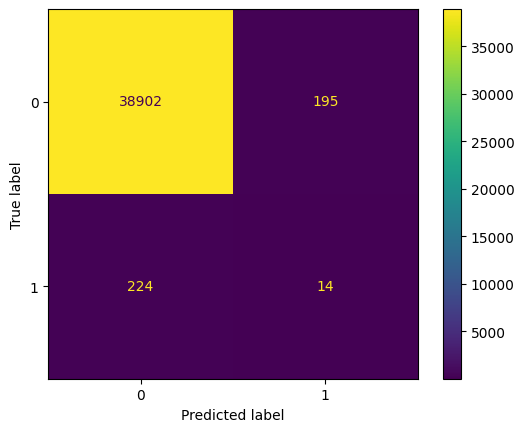


TEST report: AMBER threshold (raw)
              precision    recall  f1-score   support

           0       1.00      0.41      0.58     39097
           1       0.01      0.84      0.02       238

    accuracy                           0.41     39335
   macro avg       0.50      0.63      0.30     39335
weighted avg       0.99      0.41      0.58     39335



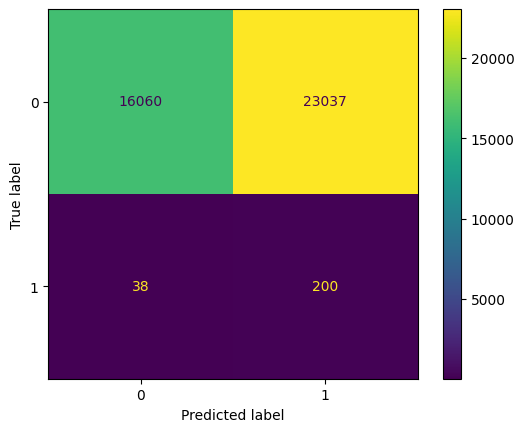

In [28]:
# __________CELL 24___________
# This cell evaluates the final model on the held-out test set for the first time.
# The thresholds come from validation, so this gives a more honest view of how the model behaves
# on data that was not used for training, model selection or threshold tuning.

test_proba = final_model.predict_proba(X_test)[:, 1]

print("\nFINAL TEST metrics (model selected on VAL, retrained on TRAIN+VAL, thresholds locked from VAL):")
print("TEST ROC-AUC:", round(roc_auc_score(y_test, test_proba), 4))
print("TEST PR-AUC: ", round(average_precision_score(y_test, test_proba), 4))

pred_red_raw   = (test_proba >= thr_red).astype(int)

cm = confusion_matrix(y_test, pred_red_raw)
print(cm)

pred_amber_raw = (test_proba >= thr_amber).astype(int)

report_binary(y_test, pred_red_raw,   "TEST report: RED threshold (raw)")
report_binary(y_test, pred_amber_raw, "TEST report: AMBER threshold (raw)")


TEST report: AMBER-or-RED (WITH hygiene, active state)
              precision    recall  f1-score   support

           0       1.00      0.40      0.57     39097
           1       0.01      0.85      0.02       238

    accuracy                           0.41     39335
   macro avg       0.50      0.63      0.30     39335
weighted avg       0.99      0.41      0.57     39335



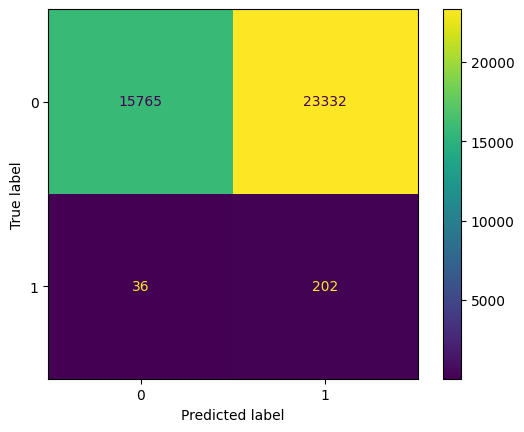


TEST report: RED only (WITH hygiene, active state)
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     39097
           1       0.04      0.08      0.06       238

    accuracy                           0.98     39335
   macro avg       0.52      0.54      0.52     39335
weighted avg       0.99      0.98      0.99     39335



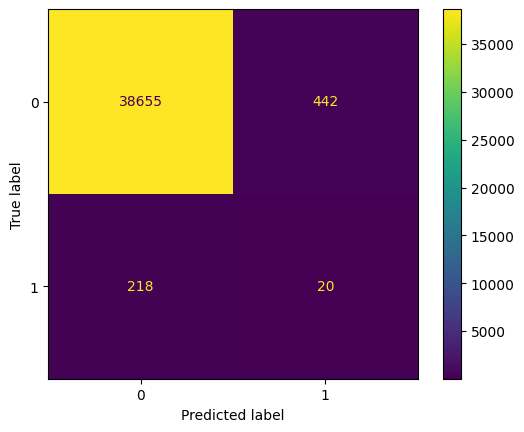

In [29]:
# __________CELL 25___________
# This cell applies the alert hygiene logic to the test predictions.
# Instead of judging each hourly score in isolation, it checks how alerts behave over time
# for each patient, including amber/red states, escalation and cooldown.

test_eval = df.loc[X_test.index, [GROUP_COL, TIME_COL]].copy()
test_eval["y_true"] = y_test.values
test_eval["risk_score"] = test_proba

test_eval = apply_alert_hygiene(
    test_eval,
    patient_col=GROUP_COL, time_col=TIME_COL, score_col="risk_score",
    thr_amber=thr_amber, thr_red=thr_red,
    k_amber=K_CONSECUTIVE_AMBER, k_red=K_CONSECUTIVE_RED,
    cooldown_hours=COOLDOWN_HOURS,
    allow_escalation=ALLOW_ESCALATION_TO_RED
)

pred_any_h = (test_eval["alert_state"] >= 1).astype(int)  
pred_red_h = (test_eval["alert_state"] == 2).astype(int)  

report_binary(test_eval["y_true"].values, pred_any_h.values, "TEST report: AMBER-or-RED (WITH hygiene, active state)")
report_binary(test_eval["y_true"].values, pred_red_h.values, "TEST report: RED only (WITH hygiene, active state)")

In [30]:
# __________CELL 26___________
# This cell counts how many alert events actually fired after the hygiene rules were applied.
# This is useful because an alerting system is not only about precision and recall;
# it also needs to show whether it would overwhelm users with too many events.

print("Amber events fired:", int((test_eval["alert_fired"] == 1).sum()))
print("Red events fired:  ", int((test_eval["alert_fired"] == 2).sum()))
print("Any alert events fired:", int((test_eval["alert_fired"] > 0).sum()))
print("Alerts fired per 1000 hours:", round(1000 * float((test_eval["alert_fired"] > 0).mean()), 2))

Amber events fired: 4153
Red events fired:   79
Any alert events fired: 4232
Alerts fired per 1000 hours: 107.59


In [31]:
# __________CELL 27___________
# This cell evaluates the predictions at patient level rather than only hourly-row level.
# This gives a more practical view, because the dashboard is meant to help identify patients
# who become concerning at any point, not just count individual rows.

patient_level = test_eval.groupby(GROUP_COL).agg(
    true_any=("y_true", "max"),
    pred_any=("alert_state", lambda s: int((s >= 1).any())),
    pred_red=("alert_state", lambda s: int((s == 2).any())),
).reset_index()

print("\nPatient-level report (ANY alert state):")
print(classification_report(patient_level["true_any"], patient_level["pred_any"], zero_division=0))

print("\nPatient-level report (RED alert state only):")
print(classification_report(patient_level["true_any"], patient_level["pred_red"], zero_division=0))


Patient-level report (ANY alert state):
              precision    recall  f1-score   support

           0       0.98      0.13      0.23       951
           1       0.05      0.96      0.10        49

    accuracy                           0.17      1000
   macro avg       0.52      0.54      0.17      1000
weighted avg       0.94      0.17      0.22      1000


Patient-level report (RED alert state only):
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       951
           1       0.75      0.24      0.37        49

    accuracy                           0.96      1000
   macro avg       0.86      0.62      0.67      1000
weighted avg       0.95      0.96      0.95      1000




Generating SHAP summary plot...


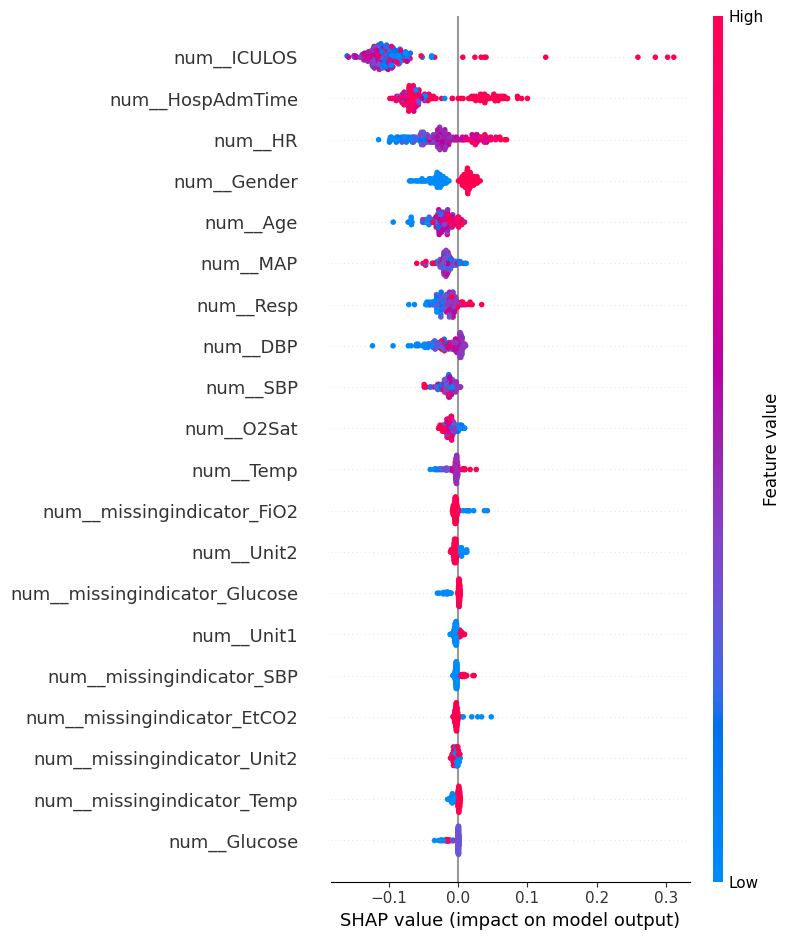

In [32]:
# __________CELL 28___________
# This cell generates SHAP explanations for a sample of held-out test rows.
# The aim is not to prove clinical causation, but to inspect which transformed features
# influenced the model's predictions and support the explanation feature used in the dashboard.

fitted_preprocess = final_model.named_steps["preprocess"]
fitted_model = final_model.named_steps["model"]

X_test_tx = fitted_preprocess.transform(X_test)
X_train_tx = fitted_preprocess.transform(X_train2)

rng = np.random.RandomState(RANDOM_STATE)
n_shap = min(N_SHAP, X_test_tx.shape[0])

idx = rng.choice(X_test_tx.shape[0], size=n_shap, replace=False)
X_shap = X_test_tx[idx]
X_shap_dense = X_shap.toarray() if hasattr(X_shap, "toarray") else X_shap


bg_n = min(200, X_train_tx.shape[0])
bg_idx = rng.choice(X_train_tx.shape[0], size=bg_n, replace=False)
X_bg = X_train_tx[bg_idx]
X_bg_dense = X_bg.toarray() if hasattr(X_bg, "toarray") else X_bg

try:
    feature_names = fitted_preprocess.get_feature_names_out()
except Exception:
    feature_names = None

print("\nGenerating SHAP summary plot...")

try:
    if isinstance(fitted_model, RandomForestClassifier):
        explainer = shap.TreeExplainer(fitted_model)
        sv = explainer.shap_values(X_shap_dense)
        sv_plot = sv[1] if isinstance(sv, list) else sv
        if hasattr(sv_plot, "ndim") and sv_plot.ndim == 3 and sv_plot.shape[-1] == 2:
            sv_plot = sv_plot[:, :, 1]
        shap.summary_plot(sv_plot, X_shap_dense, feature_names=feature_names, show=True)

    elif isinstance(fitted_model, LogisticRegression):
        try:
            explainer = shap.LinearExplainer(fitted_model, X_bg_dense)
            sv = explainer.shap_values(X_shap_dense)
            shap.summary_plot(sv, X_shap_dense, feature_names=feature_names, show=True)
        except Exception:
            explainer = shap.Explainer(fitted_model, X_bg_dense, feature_names=feature_names)
            sv_obj = explainer(X_shap_dense)
            shap.summary_plot(sv_obj.values, X_shap_dense, feature_names=feature_names, show=True)

    else:
        print("SHAP not configured for this model type.")
except Exception as e:
    print("SHAP failed:", repr(e))

In [33]:
# __________CELL 29___________
# This cell saves the final trained model and all the information the Streamlit app needs.
# Instead of retraining inside the dashboard, the app can load this bundle and reuse the same
# feature columns, thresholds, alert policy and model-selection summary.

import json


p_red_test, r_red_test = pr_at_threshold(y_test, test_proba, thr_red)
p_amb_test, r_amb_test = pr_at_threshold(y_test, test_proba, thr_amber)

bundle = {
    "base_model": final_model,
    "chosen_model": chosen_name,
    "feature_columns": X.columns.tolist(),

    "thresholds": {
        "amber": float(thr_amber),
        "red": float(thr_red),
    },

    "threshold_policy": {
        "min_precision_red": float(MIN_PRECISION_RED),
        "min_recall_amber": float(MIN_RECALL_AMBER),
        "k_consecutive_amber": int(K_CONSECUTIVE_AMBER),
        "k_consecutive_red": int(K_CONSECUTIVE_RED),
        "cooldown_hours": int(COOLDOWN_HOURS),
        "allow_escalation_to_red": bool(ALLOW_ESCALATION_TO_RED),
    },

    "config": {
        "TARGET": TARGET,
        "GROUP_COL": GROUP_COL,
        "RAW_LABEL": RAW_LABEL,
        "HORIZON_HOURS": HORIZON_HOURS,
        "RANDOM_STATE": RANDOM_STATE,
        "TEST_SIZE": TEST_SIZE,
        "USE_SUBSET_FOR_SPEED": USE_SUBSET_FOR_SPEED,
        "N_PATIENTS_SUBSET": N_PATIENTS_SUBSET,
        "DROP_ULTRA_MISSING": DROP_ULTRA_MISSING,
        "MISSING_THRESHOLD": MISSING_THRESHOLD,
        "CLEAN_OUTLIERS": CLEAN_OUTLIERS,
        "TIME_COL": TIME_COL,
    },

    "model_selection": selection_summary,
    "final_training_scheme": {
        "model_selected_on": "validation split",
        "thresholds_selected_on": "validation split",
        "final_fit_data": "train_full (train + validation)",
        "final_test_evaluated_once": True,
    },
}

results = pd.DataFrame([
    {"Split": "VAL", **lr_val_metrics},
    {"Split": "VAL", **rf_val_metrics},
{
        "Split": "TEST",
        "Model": f"FINAL ({chosen_label}, retrained on train+val)",
        "ROC_AUC": float(roc_auc_score(y_test, test_proba)),
        "PR_AUC": float(average_precision_score(y_test, test_proba)),
        "thr_amber": float(thr_amber),
        "thr_red": float(thr_red),
        "VAL_precision@red": float(p_red_val),
        "VAL_recall@red": float(r_red_val),
        "TEST_precision@red": float(p_red_test),
        "TEST_recall@red": float(r_red_test),
        "VAL_precision@amber": float(p_amb_val),
        "VAL_recall@amber": float(r_amb_val),
        "TEST_precision@amber": float(p_amb_test),
        "TEST_recall@amber": float(r_amb_test),
    }
])

comparison_path = DATA_DIR / "model_comparison_val.csv"
ranked_candidates.to_csv(comparison_path, index=False)

selection_path = DATA_DIR / "model_selection_summary.json"
with open(selection_path, "w", encoding="utf-8") as f:
    json.dump(selection_summary, f, indent=2)

results_path = DATA_DIR / "model_results.csv"
results.to_csv(results_path, index=False)

test_eval_path = DATA_DIR / "test_eval_with_alerts.parquet"
try:
    test_eval.to_parquet(test_eval_path, index=False)
    print("Saved test eval with alerts:", test_eval_path)
except Exception as e:
    fallback_csv = DATA_DIR / "test_eval_with_alerts.csv"
    test_eval.to_csv(fallback_csv, index=False)
    print("Parquet save failed, saved CSV instead:", fallback_csv)
    print("Reason:", repr(e))

model_path = MODELS_DIR / "sepsis_model_bundle.pkl"
joblib.dump(bundle, model_path)

print("\nSaved bundle:", model_path)
print("Saved results:", results_path)
print("Saved model comparison:", comparison_path)
print("Saved model selection summary:", selection_path)
display(results)

Saved test eval with alerts: c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\data\test_eval_with_alerts.parquet

Saved bundle: c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\models\sepsis_model_bundle.pkl
Saved results: c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\data\model_results.csv
Saved model comparison: c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\data\model_comparison_val.csv
Saved model selection summary: c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\data\model_selection_summary.json


,Split,Model,ROC_AUC,PR_AUC,Pos_rate,thr_amber,thr_red,VAL_precision@red,VAL_recall@red,TEST_precision@red,TEST_recall@red,VAL_precision@amber,VAL_recall@amber,TEST_precision@amber,TEST_recall@amber
0,VAL,Logistic Regression,0.677569,0.022179,0.007898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,VAL,Random Forest,0.644675,0.021849,0.007898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TEST,"FINAL (Random Forest, retrained on train+val)",0.749785,0.033230,NaN,0.163262,0.706855,0.2,0.008475,0.066986,0.058824,0.01153,0.635593,0.008607,0.840336


In [34]:
# __________CELL 30___________
# This cell writes a compact experiment summary to a CSV log.
# It keeps the main settings and final results together, which makes it easier to compare
# repeated runs 

patient_any_rep = classification_report(
    patient_level["true_any"],
    patient_level["pred_any"],
    output_dict=True,
    zero_division=0
)

patient_red_rep = classification_report(
    patient_level["true_any"],
    patient_level["pred_red"],
    output_dict=True,
    zero_division=0
)

summary_row = {
    "experiment_name": EXPERIMENT_NAME,
    "run_notes": RUN_NOTES,
    "use_subset": USE_SUBSET_FOR_SPEED,
    "n_patients_subset": int(N_PATIENTS_SUBSET) if USE_SUBSET_FOR_SPEED else None,
    "rows_used": int(len(df)),
    "patients_used": int(df[GROUP_COL].nunique()),

    "chosen_model": chosen_label,
    "selected_val_pr_auc": float(winner["VAL_PR_AUC"]),
    "selected_val_roc_auc": float(winner["VAL_ROC_AUC"]),

    "test_roc_auc": float(roc_auc_score(y_test, test_proba)),
    "test_pr_auc": float(average_precision_score(y_test, test_proba)),

    "thr_amber": float(thr_amber),
    "thr_red": float(thr_red),

    "test_precision_red_raw": float(p_red_test),
    "test_recall_red_raw": float(r_red_test),
    "test_precision_amber_raw": float(p_amb_test),
    "test_recall_amber_raw": float(r_amb_test),

    "patient_precision_any_h": float(patient_any_rep["1"]["precision"]),
    "patient_recall_any_h": float(patient_any_rep["1"]["recall"]),
    "patient_precision_red_h": float(patient_red_rep["1"]["precision"]),
    "patient_recall_red_h": float(patient_red_rep["1"]["recall"]),

    "alerts_per_1000_hours": round(1000 * float((test_eval["alert_fired"] > 0).mean()), 2),

    "runtime_minutes": round((time.perf_counter() - t_pipeline_start) / 60, 2),
}

log_path = DATA_DIR / "subset_scale_experiments.csv"

if log_path.exists():
    old_log = pd.read_csv(log_path)
    log_df = pd.concat([old_log, pd.DataFrame([summary_row])], ignore_index=True)
else:
    log_df = pd.DataFrame([summary_row])

log_df.to_csv(log_path, index=False)

print("\nSaved experiment log:", log_path)
display(log_df)


Saved experiment log: c:\Users\afcmu\Downloads\w1916669_DetectingSepsis_FYP-main\data\subset_scale_experiments.csv


,experiment_name,run_notes,use_subset,n_patients_subset,rows_used,patients_used,chosen_model,selected_val_pr_auc,selected_val_roc_auc,test_roc_auc,...,test_precision_red_raw,test_recall_red_raw,test_precision_amber_raw,test_recall_amber_raw,patient_precision_any_h,patient_recall_any_h,patient_precision_red_h,patient_recall_red_h,alerts_per_1000_hours,runtime_minutes
0,subset_5000,baseline subset,True,5000,191583,5000,Random Forest,0.021849,0.644675,0.749785,...,0.066986,0.058824,0.008607,0.840336,0.053776,0.959184,0.75,0.244898,107.59,3.55
1,subset_5000,baseline subset,True,5000,191583,5000,Random Forest,0.021849,0.644675,0.749785,...,0.066986,0.058824,0.008607,0.840336,0.053776,0.959184,0.75,0.244898,107.59,2.79
2,subset_5000,baseline subset,True,5000,191583,5000,Random Forest,0.021849,0.644675,0.749785,...,0.066986,0.058824,0.008607,0.840336,0.053776,0.959184,0.75,0.244898,107.59,3.94
3,subset_5000,baseline subset,True,5000,191583,5000,Random Forest,0.021849,0.644675,0.749785,...,0.066986,0.058824,0.008607,0.840336,0.053776,0.959184,0.75,0.244898,107.59,1.71


In [35]:
# __________CELL 31___________
# This final check prints the chosen model and the reason it was selected.
# I kept this at the end so the notebook has a clear final statement of the model-selection outcome.

print("\nChosen model:", chosen_label)
print("Reason:", selection_reason)


Chosen model: Random Forest
Reason: validation PR-AUC within ±0.001; selected by higher RED-threshold recall, then higher patient-level RED precision, then simpler model


In [ ]:
# References
# These links record the main documentation pages and sources used while building the notebook.
# I also included the AI-use note here so the support used for debugging and readability is visible,
# while making clear that the final decisions and validation were checked by me.

# Python Packaging Authority (n.d.) pip install. Available at: https://pip.pypa.io/en/stable/cli/pip_install/
# Kaggle (n.d.) KaggleHub. GitHub. Available at: https://github.com/Kaggle/kagglehub
# PyPI (n.d.) certifi. Available at: https://pypi.org/project/certifi/

# Python Software Foundation (n.d.) sys — System-specific parameters and functions. Available at: https://docs.python.org/3/library/sys.html
# Python Software Foundation (n.d.) pathlib — Object-oriented filesystem paths. Available at: https://docs.python.org/3/library/pathlib.html
# Python Software Foundation (n.d.) os — Miscellaneous operating system interfaces. Available at: https://docs.python.org/3/library/os.html
# Python Software Foundation (n.d.) glob — Unix style pathname pattern expansion. Available at: https://docs.python.org/3/library/glob.html
# Python Software Foundation (n.d.) time — Time access and conversions. Available at: https://docs.python.org/3/library/time.html
# Python Software Foundation (n.d.) json — JSON encoder and decoder. Available at: https://docs.python.org/3/library/json.html
# Python Software Foundation (n.d.) Built-in functions. Available at: https://docs.python.org/3/library/functions.html
# Python Software Foundation (n.d.) The Python Language Reference. Available at: https://docs.python.org/3/reference/index.html

# NumPy Developers (n.d.) numpy.random.RandomState.choice. Available at: https://numpy.org/doc/stable/reference/random/generated/numpy.random.RandomState.choice.html
# NumPy Developers (n.d.) numpy.zeros. Available at: https://numpy.org/doc/stable/reference/generated/numpy.zeros.html
# NumPy Developers (n.d.) numpy.argmax. Available at: https://numpy.org/doc/stable/reference/generated/numpy.argmax.html
# NumPy Developers (n.d.) numpy.where. Available at: https://numpy.org/doc/stable/reference/generated/numpy.where.html
# NumPy Developers (n.d.) numpy.asarray. Available at: https://numpy.org/doc/stable/reference/generated/numpy.asarray.html

# The pandas development team (n.d.) Input/output. Available at: https://pandas.pydata.org/docs/user_guide/io.html
# The pandas development team (n.d.) pandas.DataFrame. Available at: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html
# The pandas development team (n.d.) GroupBy. Available at: https://pandas.pydata.org/docs/reference/groupby.html

# scikit-learn developers (n.d.) GroupShuffleSplit. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupShuffleSplit.html
# scikit-learn developers (n.d.) Pipeline. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
# scikit-learn developers (n.d.) ColumnTransformer. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html
# scikit-learn developers (n.d.) SimpleImputer. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html
# scikit-learn developers (n.d.) StandardScaler. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
# scikit-learn developers (n.d.) LogisticRegression. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
# scikit-learn developers (n.d.) RandomForestClassifier. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# scikit-learn developers (n.d.) roc_auc_score. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
# scikit-learn developers (n.d.) average_precision_score. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html
# scikit-learn developers (n.d.) precision_recall_curve. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html
# scikit-learn developers (n.d.) classification_report. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
# scikit-learn developers (n.d.) confusion_matrix. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
# scikit-learn developers (n.d.) ConfusionMatrixDisplay. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
# scikit-learn developers (n.d.) clone. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.base.clone.html

# Joblib developers (n.d.) joblib.dump. Available at: https://joblib.readthedocs.io/en/latest/generated/joblib.dump.html

# SHAP contributors (n.d.) SHAP documentation. Available at: https://shap.readthedocs.io/en/latest/
# SHAP contributors (n.d.) shap.TreeExplainer. Available at: https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html
# SHAP contributors (n.d.) shap.LinearExplainer. Available at: https://shap.readthedocs.io/en/latest/generated/shap.LinearExplainer.html
# SHAP contributors (n.d.) shap.Explainer. Available at: https://shap.readthedocs.io/en/latest/generated/shap.Explainer.html

# The Matplotlib Development Team (n.d.) matplotlib.pyplot.show. Available at: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html
# IPython Development Team (n.d.) IPython documentation. Available at: https://ipython.readthedocs.io/en/stable/
# imbalanced-learn developers (n.d.) imbalanced-learn documentation. Available at: https://imbalanced-learn.org/stable/

# Hussaini, S. (n.d.) Prediction of Sepsis [Dataset]. Kaggle. Available at: https://www.kaggle.com/datasets/salikhussaini49/prediction-of-sepsis

# AI-use note:
# I used ChatGPT to help debug code issues and improve code readability.
# The final design decisions, code changes and results were tested and validated by me.